In [10]:
from matplotlib import pyplot as plt
import numpy as np

# Roofline

In [11]:
bandwidth = 192.032e9
compute = 2.71488e12

min_op_bound = compute/bandwidth
print(min_op_bound)

14.13764372604566


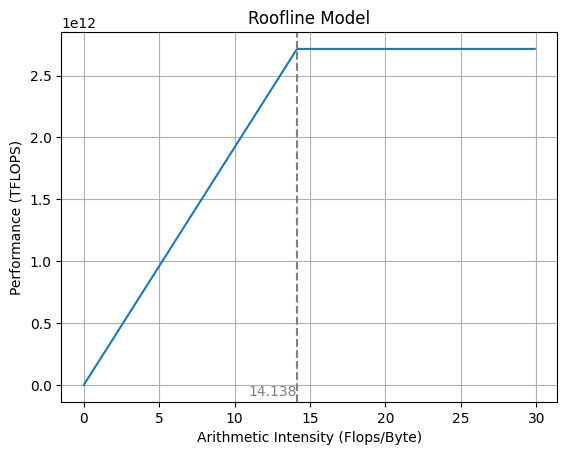

In [15]:
op = np.arange(0,30, step=.1)

bandwidth_bound = op*bandwidth
compute_bound = compute*np.ones(op.shape)
global_bound = np.minimum(bandwidth_bound, compute_bound)

plt.plot(op, global_bound)

plt.axvline(min_op_bound, color='gray', linestyle='--')
# Annotate x-axis at x=3
plt.text(min_op_bound, 0, f"{min_op_bound:.3f}", ha='right', va='top', color='gray')

plt.xlabel("Arithmetic Intensity (Flops/Byte)")
plt.ylabel("Performance (TFLOPS)")
plt.title("Roofline Model")

plt.grid()

# Coefficients

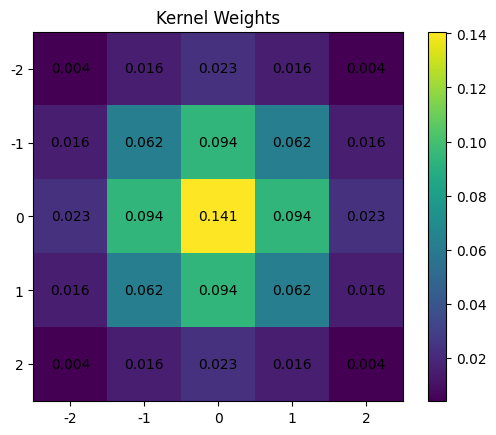

In [13]:
coef = [3/8, 1/4, 1/16]
ATROUS_RAD = 2

size = 2 * ATROUS_RAD + 1
kernel = np.zeros((size, size))

for i in range(-ATROUS_RAD, ATROUS_RAD + 1):
    for j in range(-ATROUS_RAD, ATROUS_RAD + 1):
        kernel[i + ATROUS_RAD, j + ATROUS_RAD] = coef[abs(i)] * coef[abs(j)]

fig, ax = plt.subplots()

im = ax.imshow(kernel)

ax.set_xticks(range(size))
ax.set_yticks(range(size))
ax.set_xticklabels(range(-ATROUS_RAD, ATROUS_RAD + 1))
ax.set_yticklabels(range(-ATROUS_RAD, ATROUS_RAD + 1))

for i in range(size):
    for j in range(size):
        ax.text(j, i, f"{kernel[i, j]:.3f}", ha="center", va="center")

plt.colorbar(im)
plt.title("Kernel Weights")
plt.show()